# 7. Convolutional Neural Networks

Image data is represented as a two-dimensional grid of pixels, be the image monochromatic or in color. Accordingly each pixel corresponds to one or multiple numerical values respectively. So far we have ignored this rich structure and treated images as vectors of numbers by *flattening* them, irrespective of the spatial relation between pixels. This deeply unsatisfying approach was necessary in order to feed the resulting one-dimensional vectors through a fully connected MLP.

Because these networks are invariant to the order of the features, we could get similar results regardless of whether we preserve an order corresponding to the spatial structure of the pixels or if we permute the columns of our design matrix before fitting the MLP’s parameters. Ideally, we would leverage our prior knowledge that nearby pixels are typically related to each other, to build efficient models for learning from image data.

This chapter introduces *convolutional neural networks* (CNNs) (LeCun et al., 1995), a powerful family of neural networks that are designed for precisely this purpose. CNN-based architectures are now ubiquitous in the field of computer vision. For instance, on the Imagnet collection (Deng et al., 2009) it was only the use of convolutional neural networks, in short Convnets, that provided significant performance improvements (Krizhevsky et al., 2012).

Modern CNNs, as they are called colloquially, owe their design to inspirations from biology, group theory, and a healthy dose of experimental tinkering. In addition to their sample efficiency in achieving accurate models, CNNs tend to be computationally efficient, both because they require fewer parameters than fully connected architectures and because convolutions are easy to parallelize across GPU cores (Chetlur et al., 2014). Consequently, practitioners often apply CNNs whenever possible, and increasingly they have emerged as credible competitors even on tasks with a one-dimensional sequence structure, such as audio (Abdel-Hamid et al., 2014), text (Kalchbrenner et al., 2014), and time series analysis (LeCun et al., 1995), where recurrent neural networks are conventionally used. Some clever adaptations of CNNs have also brought them to bear on graph-structured data (Kipf and Welling, 2016) and in recommender systems.

## 7.1. From Fully Connected Layers to Convolutions

To this day, the models that we have discussed so far remain appropriate options when we are dealing with tabular data. By tabular, we mean that the data consist of rows corresponding to examples and columns corresponding to features. With tabular data, we might anticipate that the patterns we seek could involve interactions among the features, but we do not assume any structure *a priori* concerning how the features interact.

Sometimes, we truly lack the knowledge to be able to guide the construction of fancier architectures. In these cases, an MLP may be the best that we can do. However, for high-dimensional perceptual data, such structureless networks can grow unwieldy.

For instance, let's return to our running example of distinguishing cats from dogs. Say that we do a thorough job in data collection, collecting an annotated dataset of one-megapixel photographs. This means that each input to the network has one million dimensions. Even an aggressive reduction to one thousand hidden dimensions would require a fully connected layer characterized by $10^6 \times 10^3 = 10^9$ parameters. Unless we have lots of GPUs, a talent for distributed optimization, and an extraordinary amount of patience, learning the parameters of this network may turn out to be infeasible.

A careful reader might object to this argument on the basis that one megapixel resolution may not be necessary. However, while we might be able to get away with one hundred thousand pixels, our hidden layer of size 1000 grossly underestimates the number of hidden units that it takes to learn good representations of images, so a practical system will still require billions of parameters. Moreover, learning a classifier by fitting so many parameters might require collecting an enormous dataset. And yet today both humans and computers are able to distinguish cats from dogs quite well, seemingly contradicting these intuitions. That is because images exhibit rich structure that can be exploited by humans and machine learning models alike. Convolutional neural networks (CNNs) are one creative way that machine learning has embraced for exploiting some of the known structure in natural images.

### 7.1.1. Invariance

Imagine that we want to detect an object in an image. It seems reasonable that whatever method we use to recognize objects should not be overly concerned with the precise location of the object in the image. Ideally, our system should exploit this knowledge. Pigs usually do not fly and planes usually do not swim. Nonetheless, we should still recognize a pig were one to appear at the top of the image. We can draw some inspiration here from the children's game "Where's Waldo" (which itself has inspired many real-life imitations, such as that depicted in Fig. 7.1.1). The game consists of a number of chaotic scenes bursting with activities. Waldo shows up somewhere in each, typically lurking in some unlikely location. The reader's goal is to locate him. Despite his characteristic outfit, this can be surprisingly difficult, due to the large number of distractions. However, *what Waldo looks like* does not depend upon *where Waldo is located*. We could sweep the image with a Waldo detector that could assign a score to each patch, indicating the likelihood that the patch contains Waldo. In fact, many object detection and segmentation algorithms are based on this approach (Long et al., 2015). CNNs systematize this idea of *spatial invariance*, exploiting it to learn useful representations with fewer parameters.

<p align="center">
  <img src="https://d2l.ai/_images/waldo-football.jpg"/>
  <br />
  <em>Fig. 7.1.1</em> Can you find Waldo (image courtesy of William Murphy (Infomatique))?
</p>

We can now make these intuitions more concrete by enumerating a few desiderata to guide our design of a neural network architecture suitable for computer vision:

1. In the earliest layers, our network should respond similarly to the same patch, regardless of where it appears in the image. This principle is called *translation invariance* (or *translation equivariance*).

2. The earliest layers of the network should focus on local regions, without regard for the contents of the image in distant regions. This is the *locality* principle. Eventually, these local representations can be aggregated to make predictions at the whole image level.

3. As we proceed, deeper layers should be able to capture longer-range features of the image, in a way similar to higher level vision in nature.

Let's see how this translates into mathematics.

### 7.1.2. Constraining the MLP

To start off, we can consider an MLP with two-dimensional images $\mathbf{X}$ as inputs and their immediate hidden representations $\mathbf{H}$ similarly represented as matrices (they are two-dimensional tensors in code), where both $\mathbf{X}$ and $\mathbf{H}$ have the same shape. Let that sink in. We now imagine that not only the inputs but also the hidden representations possess spatial structure.

Let $[\mathbf{X}]_{i, j}$ and $[\mathbf{H}]_{i, j}$ denote the pixel at location $(i,j)$ in the input image and hidden representation, respectively. Consequently, to have each of the hidden units receive input from each of the input pixels, we would switch from using weight matrices (as we did previously in MLPs) to representing our parameters as fourth-order weight tensors $\mathsf{W}$. Suppose that $\mathbf{U}$ contains biases, we could formally express the fully connected layer as

$$\begin{aligned} \left[\mathbf{H}\right]_{i, j} &= [\mathbf{U}]_{i, j} + \sum_k \sum_l[\mathsf{W}]_{i, j, k, l}  [\mathbf{X}]_{k, l}\\ &=  [\mathbf{U}]_{i, j} + \sum_a \sum_b [\mathsf{V}]_{i, j, a, b}  [\mathbf{X}]_{i+a, j+b}. \end{aligned} \tag{7.1.1}$$

The switch from $\mathsf{W}$ to $\mathsf{V}$ is entirely cosmetic for now since there is a one-to-one correspondence between coefficients in both fourth-order tensors. We simply re-index the subscripts $(k, l)$ such that $k = i+a$ and $l = j+b$. In other words, we set $[\mathsf{V}]_{i, j, a, b} = [\mathsf{W}]_{i, j, i+a, j+b}$. The indices $a$ and $b$ run over both positive and negative offsets, covering the entire image. For any given location ($i$, $j$) in the hidden representation $[\mathbf{H}]_{i, j}$, we compute its value by summing over pixels in $x$, centered around $(i, j)$ and weighted by $[\mathsf{V}]_{i, j, a, b}$. Before we carry on, let's consider the total number of parameters required for a *single* layer in this parametrization: a $1000 \times 1000$ image (1 megapixel) is mapped to a $1000 \times 1000$ hidden representation. This requires $10^{12}$ parameters, far beyond what computers currently can handle.

#### 7.1.2.1. Translation Invariance

Now let's invoke the first principle established above: translation invariance (Zhang et al., 1988). This implies that a shift in the input $\mathbf{X}$ should simply lead to a shift in the hidden representation $\mathbf{H}$. This is only possible if $\mathsf{V}$ and $\mathbf{U}$ do not actually depend on $(i, j)$. As such, we have $[\mathsf{V}]_{i, j, a, b} = [\mathbf{V}]_{a, b}$ and $\mathbf{U}$ is a constant, say $u$. As a result, we can simplify the definition for $\mathbf{H}$:

$$[\mathbf{H}]_{i, j} = u + \sum_a\sum_b [\mathbf{V}]_{a, b}  [\mathbf{X}]_{i+a, j+b}. \tag{7.1.2} $$

This is a *convolution*! We are effectively weighting pixels at $(i+a, j+b)$ in the vicinity of location $(i, j)$ with coefficients $[\mathbf{V}]_{a, b}$ to obtain the value $[\mathbf{H}]_{i, j}$. Note that $[\mathbf{V}]_{a, b}$ needs many fewer coefficients than $[\mathsf{V}]_{i, j, a, b}$ since it no longer depends on the location within the image. Consequently, the number of parameters required is no longer $10^{12}$ but a much more reasonable $4 \times 10^6$: we still have the dependency on $a, b \in (-1000, 1000)$. In short, we have made significant progress. Time-delay neural networks (TDNNs) are some of the first examples to exploit this idea (Waibel et al., 1989).

---

牧之：CNN 也是可以从 MLP 的主流思路中演变过来的，只不过是针对图像数据，用了一些归纳偏置做了模型简化。

---

牧之：为什么我觉得平移不变性对分类任务是合理的，但是对诸如对物体分割之类的任务是不合理的？因为如果图像的位置发生变化，那么物体的边缘理论上也会发生变化。那么为什么 CNN 还是可以用于这么多图像类任务呢？

#### 7.1.2.2. Locality

Now let's invoke the second principle: locality. As motivated above, we believe that we should not have to look very far away from location $(i, j)$ in order to glean relevant information to assess what is going on at $[\mathbf{H}]_{i, j}$. This means that outside some range $|a|> \Delta$ or $|b| > \Delta$, we should set $[\mathbf{V}]_{a, b} = 0$. Equivalently, we can rewrite $[\mathbf{H}]_{i, j}$ as

\begin{equation}
[\mathbf{H}]_{i, j} = u + \sum_{a = -\Delta}^{\Delta} \sum_{b = -\Delta}^{\Delta} [\mathbf{V}]_{a, b}  [\mathbf{X}]_{i+a, j+b}. \tag{7.1.3}
\end{equation}

This reduces the number of parameters from $4 \times 10^6$ to $4 \Delta^2$, where $\Delta$ is typically smaller than $10$. As such, we reduced the number of parameters by another four orders of magnitude. Note that (7.1.3), is what is called, in a nutshell, a *convolutional layer*. *Convolutional neural networks* (CNNs) are a special family of neural networks that contain convolutional layers. In the deep learning research community, $\mathbf{V}$ is referred to as a *convolution kernel*, a *filter*, or simply the layer's *weights* that are learnable parameters.

While previously, we might have required billions of parameters to represent just a single layer in an image-processing network, we now typically need just a few hundred, without altering the dimensionality of either the inputs or the hidden representations. The price paid for this drastic reduction in parameters is that our features are now translation invariant and that our layer can only incorporate local information, when determining the value of each hidden activation. *All learning depends on imposing inductive bias*. When that bias agrees with reality, we get sample-efficient models that generalize well to unseen data. But of course, if those biases do not agree with reality, e.g., if images turned out not to be translation invariant, our models might struggle even to fit our training data.

This dramatic reduction in parameters brings us to our last desideratum, namely that deeper layers should represent larger and more complex aspects of an image. This can be achieved by interleaving nonlinearities and convolutional layers repeatedly.

---

**卷积神经网络（CNN）的核心设计原理**

CNN 通过引入三个关键原则，将传统全连接层的参数量从不可行降至极低水平，同时有效建模图像数据：

1、**保留空间结构**（Preserving Spatial Structure）
> 输入 $\mathbf{X}$ 与隐藏表示 $\mathbf{H}$ 均保持二维形状，不展平为向量。  
> 承认像素位置 $(i,j)$ 具有语义意义，邻近像素相关性强。

- 这是后续引入卷积操作的前提。

2、**平移不变性**（Translation Invariance）
> 输入平移 ⇒ 输出相应平移。

- 要求权重与绝对位置无关：  
  $$
  [\mathsf{V}]_{i,j,a,b} = [\mathbf{V}]_{a,b}, \quad \mathbf{U} = u \ (\text{常数})
  $$
- 隐藏表示变为：
  $$
  [\mathbf{H}]_{i,j} = u + \sum_{a}\sum_{b} [\mathbf{V}]_{a,b} \, [\mathbf{X}]_{i+a,\,j+b}
  $$
- 实现**权重共享**，参数从 $O(n^4)$ 降至 $O(n^2)$（$n$ 为图像边长）。

3、**局部性**（Locality）
> 每个输出仅依赖输入的局部邻域。

- 限制卷积核范围：当 $|a| > \Delta$ 或 $|b| > \Delta$ 时，$[\mathbf{V}]_{a,b} = 0$。
- 卷积层定义：
  $$
  [\mathbf{H}]_{i,j} = u + \sum_{a=-\Delta}^{\Delta} \sum_{b=-\Delta}^{\Delta} [\mathbf{V}]_{a,b} \, [\mathbf{X}]_{i+a,\,j+b}
  $$
- 参数进一步降至 $O(\Delta^2)$（通常 $\Delta < 10$，如 $3\times3$ 核仅需 9 个权重）。

4、**深度堆叠**（Depth Stacking）：层次化特征学习
- 交替使用**卷积 + 非线性激活**，构建深层网络；
- 浅层捕获边缘/纹理，深层组合为复杂语义结构；
- 通过堆叠扩大**有效感受野**，克服单层局部性限制。

**核心思想**

> **所有有效学习都依赖归纳偏置**。  
> CNN 的成功源于对图像本质的合理假设：**保留空间结构 + 局部相关性 + 平移不变性**。  
> 若假设成立 → 高效泛化；若不成立 → 模型受限。

### 7.1.3. Convolutions

Let's briefly review why (7.1.3) is called a convolution. In mathematics, the *convolution* between two functions (Rudin, 1973), say $f, g: \mathbb{R}^d \to \mathbb{R}$ is defined as

\begin{equation}
(f * g)(\mathbf{x}) = \int f(\mathbf{z}) g(\mathbf{x}-\mathbf{z}) d\mathbf{z}. \tag{7.1.4}
\end{equation}

That is, we measure the overlap between $f$ and $g$ when one function is "flipped" and shifted by $\mathbf{x}$. Whenever we have discrete objects, the integral turns into a sum. For instance, for vectors from the set of square-summable infinite-dimensional vectors with index running over $\mathbb{Z}$ we obtain the following definition:

\begin{equation}
(f * g)(i) = \sum_a f(a) g(i-a). \tag{7.1.5}
\end{equation}

For two-dimensional tensors, we have a corresponding sum with indices $(a, b)$ for $f$ and $(i-a, j-b)$ for $g$, respectively:

\begin{equation}
(f * g)(i, j) = \sum_a\sum_b f(a, b) g(i-a, j-b). \tag{7.1.6}
\end{equation}

This looks similar to (7.1.3), with one major difference. Rather than using $(i+a, j+b)$, we are using the difference instead. Note, though, that this distinction is mostly cosmetic since we can always match the notation between (7.1.3) and (7.1.6). Our original definition in (7.1.3) more properly describes a *cross-correlation*. We will come back to this in the following section.

### 7.1.4. Channels

There is just one problem with this approach. So far, we blissfully ignored that images consist of three channels: red, green, and blue. In sum, images are not two-dimensional objects but rather third-order tensors, characterized by a height, width, and channel, e.g., with shape $1024 \times 1024 \times 3$ pixels. While the first two of these axes concern spatial relationships, the third can be regarded as assigning a multidimensional representation to each pixel location. We thus index $\mathsf{X}$ as $[\mathsf{X}]_{i, j, k}$. The convolutional filter has to adapt accordingly. Instead of $[\mathbf{V}]_{a,b}$, we now have $[\mathsf{V}]_{a,b,c}$.

Moreover, just as our input consists of a third-order tensor, it turns out to be a good idea to similarly formulate our hidden representations as third-order tensors $\mathsf{H}$. In other words, rather than just having a single hidden representation corresponding to each spatial location, we want an entire vector of hidden representations corresponding to each spatial location. We could think of the hidden representations as comprising a number of two-dimensional grids stacked on top of each other. As in the inputs, these are sometimes called *channels*. They are also sometimes called *feature maps*, as each provides a spatialized set of learned features for the subsequent layer. Intuitively, you might imagine that at lower layers that are closer to inputs, some channels could become specialized to recognize edges while others could recognize textures.

To support multiple channels in both inputs ($\mathsf{X}$) and hidden representations ($\mathsf{H}$), we can add a fourth coordinate to $\mathsf{V}$: $[\mathsf{V}]_{a, b, c, d}$. Putting everything together we have:

\begin{equation} [\mathsf{H}]_{i,j,d} = \sum_{a = -\Delta}^{\Delta} \sum_{b = -\Delta}^{\Delta} \sum_c [\mathsf{V}]_{a, b, c, d} [\mathsf{X}]_{i+a, j+b, c}, \tag{7.1.7} \end{equation}

where $d$ indexes the output channels in the hidden representations $\mathsf{H}$. The subsequent convolutional layer will go on to take a third-order tensor, $\mathsf{H}$, as input. We take (7.1.7), because of its generality, as the definition of a convolutional layer for multiple channels, where $\mathsf{V}$ is a kernel or filter of the layer.

There are still many operations that we need to address. For instance, we need to figure out how to combine all the hidden representations to a single output, e.g., whether there is a Waldo *anywhere* in the image. We also need to decide how to compute things efficiently, how to combine multiple layers, appropriate activation functions, and how to make reasonable design choices to yield networks that are effective in practice. We turn to these issues in the remainder of the chapter.

### 7.1.5. Summary and Discussion

In this section we derived the structure of convolutional neural networks from first principles. While it is unclear whether this was the route taken to the invention of CNNs, it is satisfying to know that they are the *right* choice when applying reasonable principles to how image processing and computer vision algorithms should operate, at least at lower levels. In particular, translation invariance in images implies that all patches of an image will be treated in the same manner. Locality means that only a small neighborhood of pixels will be used to compute the corresponding hidden representations. Some of the earliest references to CNNs are in the form of the Neocognitron (Fukushima, 1982).

A second principle that we encountered in our reasoning is how to reduce the number of parameters in a function class without limiting its expressive power, at least, whenever certain assumptions on the model hold. We saw a dramatic reduction of complexity as a result of this restriction, turning computationally and statistically infeasible problems into tractable models.

***Adding channels allowed us to bring back some of the complexity that was lost due to the restrictions imposed on the convolutional kernel by locality and translation invariance***. Note that it is quite natural to add channels other than just red, green, and blue. Many satellite images, in particular for agriculture and meteorology, have tens to hundreds of channels, generating hyperspectral images instead. They report data on many different wavelengths. In the following we will see how to use convolutions effectively to manipulate the dimensionality of the images they operate on, how to *move from location-based to channel-based representations*, and how to deal with large numbers of categories efficiently.

### 7.1.6. Exercises

1. Assume that the size of the convolution kernel is $\Delta = 0$. Show that in this case the convolution kernel implements an MLP independently for each set of channels. This leads to the Network in Network architectures (Lin et al., 2013).

1. Audio data is often represented as a one-dimensional sequence.
    - When might you want to impose locality and translation invariance for audio?
    - Derive the convolution operations for audio.
    - Can you treat audio using the same tools as computer vision? Hint: use the spectrogram.

1. Why might translation invariance not be a good idea after all? Give an example.

1. Do you think that convolutional layers might also be applicable for text data? Which problems might you encounter with language?

1. What happens with convolutions when an object is at the boundary of an image?

1. Prove that the convolution is symmetric, i.e., $f * g = g * f$.

## 7.2. Convolutions for Images

Now that we understand how convolutional layers work in theory, we are ready to see how they work in practice. Building on our motivation of convolutional neural networks as efficient architectures for exploring structure in image data, we stick with images as our running example.

In [1]:
import torch
from torch import nn

### 7.2.1. The Cross-Correlation Operation

Recall that strictly speaking, convolutional layers are a  misnomer, since the operations they express are more accurately described as cross-correlations. Based on our descriptions of convolutional layers in Section 7.1, in such a layer, an input tensor and a kernel tensor are combined to produce an output tensor through a cross-correlation operation.

Let's ignore channels for now and see how this works with two-dimensional data and hidden representations. In Fig. 7.2.1, the input is a two-dimensional tensor with a height of 3 and width of 3. We mark the shape of the tensor as $3 \times 3$ or ($3$, $3$). The height and width of the kernel are both 2. The shape of the *kernel window* (or *convolution window*) is given by the height and width of the kernel (here it is $2 \times 2$).

<p align="center">
  <img src="http://d2l.ai/_images/correlation.svg"/>
  <br />
  <em>Fig. 7.2.1</em> Two-dimensional cross-correlation operation. The shaded portions are the first output element as well as the input and kernel tensor elements used for the output computation: $0\times0+1\times1+3\times2+4\times3=19$.
</p>

...

Note that along each axis, the output size is slightly smaller than the input size. Because the kernel has width and height greater than $1$, we can only properly compute the cross-correlation for locations where the kernel fits wholly within the image, the output size is given by the input size $n_\textrm{h} \times n_\textrm{w}$ minus the size of the convolution kernel $k_\textrm{h} \times k_\textrm{w}$ via

$$(n_\textrm{h}-k_\textrm{h}+1) \times (n_\textrm{w}-k_\textrm{w}+1). \tag{7.2.2}$$

This is the case since we need enough space to "shift" the convolution kernel across the image. Later we will see how to keep the size unchanged by padding the image with zeros around its boundary so that there is enough space to shift the kernel. Next, we implement this process in the `corr2d` function, which accepts an input tensor `X` and a kernel tensor `K` and returns an output tensor `Y`.

In [2]:
def corr2d(X, K):
    """Compute 2D cross-correlation."""
    h, w = K.shape
    Y = torch.zeros((X.shape[0] - h + 1, X.shape[1] - w + 1))
    for i in range(Y.shape[0]):
        for j in range(Y.shape[1]):
            Y[i, j] = (X[i:i + h, j:j + w] * K).sum()
    return Y

We can construct the input tensor `X` and the kernel tensor `K` from Fig. 7.2.1 to validate the output of the above implementation of the two-dimensional cross-correlation operation.

In [3]:
X = torch.tensor([[0.0, 1.0, 2.0], [3.0, 4.0, 5.0], [6.0, 7.0, 8.0]])
K = torch.tensor([[0.0, 1.0], [2.0, 3.0]])
corr2d(X, K)

tensor([[19., 25.],
        [37., 43.]])

### 7.2.2. Convolutional Layers

A convolutional layer cross-correlates the input and kernel and adds a scalar bias to produce an output. The two parameters of a convolutional layer are the kernel and the scalar bias. When training models based on convolutional layers, we typically initialize the kernels randomly, just as we would with a fully connected layer.

We are now ready to implement a two-dimensional convolutional layer based on the `corr2d` function defined above. In the `__init__` constructor method, we declare `weight` and `bias` as the two model parameters. The forward propagation method calls the `corr2d` function and adds the bias.

In [4]:
class Conv2D(nn.Module):
    def __init__(self, kernel_size):
        super().__init__()
        self.weight = nn.Parameter(torch.rand(kernel_size))
        self.bias = nn.Parameter(torch.zeros(1))

    def forward(self, x):
        return corr2d(x, self.weight) + self.bias

In $h \times w$ convolution or an $h \times w$ convolution kernel, the height and width of the convolution kernel are $h$ and $w$, respectively. We also refer to a convolutional layer with an $h \times w$ convolution kernel simply as an $h \times w$ convolutional layer.

### 7.2.3. Object Edge Detection in Images

Let's take a moment to parse a simple application of a convolutional layer: detecting the edge of an object in an image by finding the location of the pixel change. First, we construct an "image" of $6\times 8$ pixels. The middle four columns are black ($0$) and the rest are white ($1$).

In [5]:
X = torch.ones((6, 8))
X[:, 2:6] = 0
X

tensor([[1., 1., 0., 0., 0., 0., 1., 1.],
        [1., 1., 0., 0., 0., 0., 1., 1.],
        [1., 1., 0., 0., 0., 0., 1., 1.],
        [1., 1., 0., 0., 0., 0., 1., 1.],
        [1., 1., 0., 0., 0., 0., 1., 1.],
        [1., 1., 0., 0., 0., 0., 1., 1.]])

Next, we construct a kernel `K` with a height of 1 and a width of 2. When we perform the cross-correlation operation with the input, if the horizontally adjacent elements are the same, the output is 0. Otherwise, the output is nonzero. Note that this kernel is a special case of a finite difference operator. At location $(i,j)$ it computes $x_{i,j} - x_{(i+1),j}$, i.e., it computes the difference between the values of horizontally adjacent pixels. This is a discrete approximation of the first derivative in the horizontal direction. After all, for a function $f(i,j)$ its derivative $-\partial_i f(i,j) = \lim_{\epsilon \to 0} \frac{f(i,j) - f(i+\epsilon,j)}{\epsilon}$. Let's see how this works in practice.

In [6]:
K = torch.tensor([[1.0, -1.0]])

We are ready to perform the cross-correlation operation with arguments `X` (our input) and `K` (our kernel). As you can see, we detect $1$ for the edge from white to black and $-1$ for the edge from black to white. All other outputs take value $0$.

In [7]:
Y = corr2d(X, K)
Y

tensor([[ 0.,  1.,  0.,  0.,  0., -1.,  0.],
        [ 0.,  1.,  0.,  0.,  0., -1.,  0.],
        [ 0.,  1.,  0.,  0.,  0., -1.,  0.],
        [ 0.,  1.,  0.,  0.,  0., -1.,  0.],
        [ 0.,  1.,  0.,  0.,  0., -1.,  0.],
        [ 0.,  1.,  0.,  0.,  0., -1.,  0.]])

We can now apply the kernel to the transposed image. As expected, it vanishes. The kernel `K` only detects vertical edges.

In [8]:
corr2d(X.t(), K)

tensor([[0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0.]])

### 7.2.4. Learning a Kernel

Designing an edge detector by finite differences `[1, -1]` is neat if we know this is precisely what we are looking for. However, as we look at larger kernels, and consider successive layers of convolutions, it might be impossible to specify precisely what each filter should be doing manually.

Now let's see whether we can learn the kernel that generated `Y` from `X` by looking at the input--output pairs only. We first construct a convolutional layer and initialize its kernel as a random tensor. Next, in each iteration, we will use the squared error to compare `Y` with the output of the convolutional layer. We can then calculate the gradient to update the kernel. For the sake of simplicity, in the following we use the built-in class for two-dimensional convolutional layers and ignore the bias.

In [9]:
# Construct a two-dimensional convolutional layer with 1 output channel and a
# kernel of shape (1, 2). For the sake of simplicity, we ignore the bias here
conv2d = nn.LazyConv2d(1, kernel_size=(1, 2), bias=False)

# The two-dimensional convolutional layer uses four-dimensional input and
# output in the format of (example, channel, height, width), where the batch
# size (number of examples in the batch) and the number of channels are both 1
X = X.reshape((1, 1, 6, 8))
Y = Y.reshape((1, 1, 6, 7))
lr = 3e-2  # Learning rate

for i in range(10):
    Y_hat = conv2d(X)
    l = (Y_hat - Y) ** 2
    conv2d.zero_grad()
    l.sum().backward()
    # Update the kernel
    conv2d.weight.data[:] -= lr * conv2d.weight.grad
    if (i + 1) % 2 == 0:
        print(f'epoch {i + 1}, loss {l.sum():.3f}')

epoch 2, loss 7.512
epoch 4, loss 2.307
epoch 6, loss 0.816
epoch 8, loss 0.312
epoch 10, loss 0.124


/home/lancer/miniforge3/envs/d2l/lib/python3.10/site-packages/torch/nn/modules/lazy.py:181: UserWarning: Lazy modules are a new feature under heavy development so changes to the API or functionality can happen at any moment.
  warnings.warn('Lazy modules are a new feature under heavy development '


Note that the error has dropped to a small value after 10 iterations. Now we will take a look at the kernel tensor we learned.

In [10]:
conv2d.weight.data.reshape((1, 2))

tensor([[ 1.0268, -0.9547]])

Indeed, the learned kernel tensor is remarkably close to the kernel tensor `K` we defined earlier.

### 7.2.5. Cross-Correlation and Convolution

Recall our observation from Section 7.1 of the correspondence between the cross-correlation and convolution operations. Here let's continue to consider two-dimensional convolutional layers. What if such layers perform strict convolution operations as defined in (7.1.6) instead of cross-correlations? In order to obtain the output of the strict *convolution* operation, we only need to flip the two-dimensional kernel tensor both horizontally and vertically, and then perform the *cross-correlation* operation with the input tensor.

It is noteworthy that since kernels are learned from data in deep learning, the outputs of convolutional layers remain unaffected no matter such layers perform either the strict convolution operations or the cross-correlation operations.

To illustrate this, suppose that a convolutional layer performs *cross-correlation* and learns the kernel in Fig. 7.2.1, which is here denoted as the matrix $\mathbf{K}$. Assuming that other conditions remain unchanged, when this layer instead performs strict *convolution*, the learned kernel $\mathbf{K}'$ will be the same as $\mathbf{K}$ after $\mathbf{K}'$ is flipped both horizontally and vertically. That is to say, when the convolutional layer performs strict *convolution* for the input in Fig. 7.2.1 and $\mathbf{K}'$, the same output in Fig. 7.2.1 (cross-correlation of the input and $\mathbf{K}$) will be obtained.

In keeping with standard terminology in deep learning literature, we will continue to refer to the cross-correlation operation as a convolution even though, strictly-speaking, it is slightly different. Furthermore, we use the term *element* to refer to an entry (or component) of any tensor representing a layer representation or a convolution kernel.

### 7.2.6. Feature Map and Receptive Field

As described in Section 7.1.4, the convolutional layer output in Fig. 7.2.1 is sometimes called a *feature map*, as it can be regarded as the learned representations (features) in the spatial dimensions (e.g., width and height) to the subsequent layer. In CNNs, for any element $x$ of some layer, its *receptive field* refers to all the elements (from all the previous layers) that may affect the calculation of $x$ during the forward propagation. Note that the receptive field may be larger than the actual size of the input.

Let's continue to use Fig. 7.2.1 to explain the receptive field. Given the $2 \times 2$ convolution kernel, the receptive field of the shaded output element (of value $19$) is the four elements in the shaded portion of the input. Now let's denote the $2 \times 2$ output as $\mathbf{Y}$ and consider a deeper CNN with an additional $2 \times 2$ convolutional layer that takes $\mathbf{Y}$ as its input, outputting a single element $z$. In this case, the receptive field of $z$ on $\mathbf{Y}$ includes all the four elements of $\mathbf{Y}$, while the receptive field on the input includes all the nine input elements. Thus, when any element in a feature map needs a larger receptive field to detect input features over a broader area, we can build a deeper network.

Receptive fields derive their name from neurophysiology. A series of experiments on a range of animals using different stimuli (Hubel and Wiesel, 1959, Hubel and Wiesel, 1962, Hubel and Wiesel, 1968) explored the response of what is called the visual cortex on said stimuli. By and large they found that lower levels respond to edges and related shapes. Later on, Field (1987) illustrated this effect on natural images with, what can only be called, convolutional kernels. We reprint a key figure in Fig. 7.2.2 to illustrate the striking similarities.

<p align="center">
  <img src="https://d2l.ai/_images/field-visual.png"/>
  <br />
  <em>Fig. 7.2.2</em> Figure and caption taken from Field (1987): An example of coding with six different channels. (Left) Examples of the six types of sensor associated with each channel. (Right) Convolution of the image in (Middle) with the six sensors shown in (Left). The response of the individual sensors is determined by sampling these filtered images at a distance proportional to the size of the sensor (shown with dots). This diagram shows the response of only the even symmetric sensors.
</p>

As it turns out, this relation even holds for the features computed by deeper layers of networks trained on image classification tasks, as demonstrated in, for example, Kuzovkin et al. (2018). Suffice it to say, convolutions have proven to be an incredibly powerful tool for computer vision, both in biology and in code. As such, it is not surprising (in hindsight) that they heralded the recent success in deep learning.

### 7.2.7. Summary

The core computation required for a convolutional layer is a cross-correlation operation. We saw that a simple nested for-loop is all that is required to compute its value. If we have multiple input and multiple output channels, we are  performing a matrix--matrix operation between channels. As can be seen, the computation is straightforward and, most importantly, highly *local*. This affords significant hardware optimization and many recent results in computer vision are only possible because of that. After all, it means that chip designers can invest in fast computation rather than memory when it comes to optimizing for convolutions. While this may not lead to optimal designs for other applications, it does open the door to ubiquitous and affordable computer vision.

In terms of convolutions themselves, they can be used for many purposes, for example detecting edges and lines, blurring images, or sharpening them. Most importantly, it is not necessary that the statistician (or engineer) invents suitable filters. Instead, we can simply *learn* them from data. This replaces feature engineering heuristics by evidence-based statistics. Lastly, and quite delightfully, these filters are not just advantageous for building deep networks but they also correspond to receptive fields and feature maps in the brain. This gives us confidence that we are on the right track.

### 7.2.8. Exercises

1. Construct an image `X` with diagonal edges.
  - What happens if you apply the kernel `K` in this section to it?
  - What happens if you transpose `X`?
  - What happens if you transpose `K`?

1. Design some kernels manually.
  - Given a directional vector $\mathbf{v} = (v_1, v_2)$, derive an edge-detection kernel that detects edges orthogonal to $\mathbf{v}$, i.e., edges in the direction $(v_2, -v_1)$.
  - Derive a finite difference operator for the second derivative. What is the minimum size of the convolutional kernel associated with it? Which structures in images respond most strongly to it?
  - How would you design a blur kernel? Why might you want to use such a kernel?
  - What is the minimum size of a kernel to obtain a derivative of order $d$?

1. When you try to automatically find the gradient for the `Conv2D` class we created, what kind of error message do you see?

1. How do you represent a cross-correlation operation as a matrix multiplication by changing the input and kernel tensors?

## 7.3. Padding and Stride

---
牧之：
省流版：通常情况下，CNN 的前几层用于检测图像表征，需要通过多层结构获得更大的感受野，从而可以学习图像中的整体信息。多层卷积网络会降低图像的空间分辨率，可以通过 padding 在卷积时保持空间分辨率，可以通过 stride 在卷积时快速降低空间分辨率。

...

In the following we will explore a number of techniques, including padding and strided convolutions, that offer more control over the size of the output. As motivation, note that since kernels generally have width and height greater than $1$, after applying many successive convolutions, we tend to wind up with outputs that are considerably smaller than our input. If we start with a $240 \times 240$ pixel image, ten layers of $5 \times 5$ convolutions reduce the image to $200 \times 200$ pixels, slicing off $30 \%$ of the image and with it obliterating any interesting information on the boundaries of the original image. *Padding* is the most popular tool for handling this issue. In other cases, we may want to reduce the dimensionality drastically, e.g., if we find the original input resolution to be unwieldy. *Strided convolutions* are a popular technique that can help in these instances.

In [11]:
import torch
from torch import nn

### 7.3.1. Padding

...

In general, if we add a total of $p_\textrm{h}$ rows of padding (roughly half on top and half on bottom) and a total of $p_\textrm{w}$ columns of padding (roughly half on the left and half on the right), the output shape will be

$$(n_\textrm{h}-k_\textrm{h}+p_\textrm{h}+1)\times(n_\textrm{w}-k_\textrm{w}+p_\textrm{w}+1). \tag{7.3.1}$$

This means that the height and width of the output will increase by $p_\textrm{h}$ and $p_\textrm{w}$, respectively.

In many cases, we will want to set $p_\textrm{h}=k_\textrm{h}-1$ and $p_\textrm{w}=k_\textrm{w}-1$ to give the input and output the same height and width. This will make it easier to predict the output shape of each layer when constructing the network. Assuming that $k_\textrm{h}$ is odd here, we will pad $p_\textrm{h}/2$ rows on both sides of the height. If $k_\textrm{h}$ is even, one possibility is to pad $\lceil p_\textrm{h}/2\rceil$ rows on the top of the input and $\lfloor p_\textrm{h}/2\rfloor$ rows on the bottom. We will pad both sides of the width in the same way.

CNNs commonly use convolution kernels with odd height and width values, such as 1, 3, 5, or 7. Choosing odd kernel sizes has the benefit that we can preserve the dimensionality while padding with the same number of rows on top and bottom, and the same number of columns on left and right.

Moreover, this practice of using odd kernels and padding to precisely preserve dimensionality offers a clerical benefit. For any two-dimensional tensor `X`, when the kernel's size is odd and the number of padding rows and columns on all sides are the same, thereby producing an output with the same height and width as the input, we know that the output `Y[i, j]` is calculated by cross-correlation of the input and convolution kernel with the window centered on `X[i, j]`.

In the following example, we create a two-dimensional convolutional layer with a height and width of 3 and apply 1 pixel of padding on all sides. Given an input with a height and width of 8, we find that the height and width of the output is also 8.

In [12]:
# We define a helper function to calculate convolutions. It initializes the
# convolutional layer weights and performs corresponding dimensionality
# elevations and reductions on the input and output
def comp_conv2d(conv2d, X):
    # (1, 1) indicates that batch size and the number of channels are both 1
    X = X.reshape((1, 1) + X.shape)  # 注意元组相加是拼接
    Y = conv2d(X)
    # Strip the first two dimensions: examples and channels
    return Y.reshape(Y.shape[2:])

# 1 row and column is padded on either side, so a total of 2 rows or columns
# are added
conv2d = nn.LazyConv2d(1, kernel_size=3, padding=1)
X = torch.rand(size=(8, 8))
comp_conv2d(conv2d, X).shape

torch.Size([8, 8])

When the height and width of the convolution kernel are different, we can make the output and input have the same height and width by setting different padding numbers for height and width.

In [13]:
# We use a convolution kernel with height 5 and width 3. The padding on either
# side of the height and width are 2 and 1, respectively
conv2d = nn.LazyConv2d(1, kernel_size=(5, 3), padding=(2, 1))
comp_conv2d(conv2d, X).shape

torch.Size([8, 8])

### 7.3.2. Stride

When computing the cross-correlation, we start with the convolution window at the upper-left corner of the input tensor, and then slide it over all locations both down and to the right. In the previous examples, we defaulted to sliding one element at a time. However, sometimes, either for computational efficiency or because we wish to downsample, we move our window more than one element at a time, skipping the intermediate locations. This is particularly useful if the convolution kernel is large since it captures a large area of the underlying image.

...

In general, when the stride for the height is $s_\textrm{h}$ and the stride for the width is $s_\textrm{w}$, the output shape is

$$\lfloor(n_\textrm{h}-k_\textrm{h}+p_\textrm{h}+s_\textrm{h})/s_\textrm{h}\rfloor \times \lfloor(n_\textrm{w}-k_\textrm{w}+p_\textrm{w}+s_\textrm{w})/s_\textrm{w}\rfloor. \tag{7.3.2} $$

If we set $p_\textrm{h}=k_\textrm{h}-1$ and $p_\textrm{w}=k_\textrm{w}-1$, then the output shape can be simplified to $\lfloor(n_\textrm{h}+s_\textrm{h}-1)/s_\textrm{h}\rfloor \times \lfloor(n_\textrm{w}+s_\textrm{w}-1)/s_\textrm{w}\rfloor$. Going a step further, if the input height and width are divisible by the strides on the height and width, then the output shape will be $(n_\textrm{h}/s_\textrm{h}) \times (n_\textrm{w}/s_\textrm{w})$.

Below, we set the strides on both the height and width to 2, thus halving the input height and width.

In [15]:
conv2d = nn.LazyConv2d(1, kernel_size=3, padding=1, stride=2)
comp_conv2d(conv2d, X).shape

torch.Size([4, 4])

Let’s look at a slightly more complicated example.

In [16]:
conv2d = nn.LazyConv2d(1, kernel_size=(3, 5), padding=(0, 1), stride=(3, 4))
comp_conv2d(conv2d, X).shape

torch.Size([2, 2])

### 7.3.3. Summary and Discussion

Padding can increase the height and width of the output. This is often used to give the output the same height and width as the input to avoid undesirable shrinkage of the output. Moreover, it ensures that all pixels are used equally frequently. Typically we pick symmetric padding on both sides of the input height and width. In this case we refer to $(p_\textrm{h}, p_\textrm{w})$ padding. Most commonly we set $p_\textrm{h} = p_\textrm{w}$, in which case we simply state that we choose padding $p$.

A similar convention applies to strides. When horizontal stride $s_\textrm{h}$ and vertical stride $s_\textrm{w}$ match, we simply talk about stride $s$. The stride can reduce the resolution of the output, for example reducing the height and width of the output to only $1/n$ of the height and width of the input for $n > 1$. By default, the padding is 0 and the stride is 1.

So far all padding that we discussed simply extended images with zeros. This has significant computational benefit since it is trivial to accomplish. Moreover, operators can be engineered to take advantage of this padding implicitly without the need to allocate additional memory. At the same time, it allows CNNs to encode implicit position information within an image, simply by learning where the "whitespace" is. There are many alternatives to zero-padding. Alsallakh et al. (2020) provided an extensive overview of those (albeit without a clear case for when to use nonzero paddings unless artifacts occur).

### 7.3.4. Exercises

1. Given the final code example in this section with kernel size $(3, 5)$, padding $(0, 1)$, and stride $(3, 4)$, calculate the output shape to check if it is consistent with the experimental result.

1. For audio signals, what does a stride of 2 correspond to?

1. Implement mirror padding, i.e., padding where the border values are simply mirrored to extend tensors.

1. What are the computational benefits of a stride larger than 1?

1. What might be statistical benefits of a stride larger than 1?

1. How would you implement a stride of $\frac{1}{2}$? What does it correspond to? When would this be useful?

## 7.4. Multiple Input and Multiple Output Channels

When we add channels into the mix, our inputs and hidden representations both become three-dimensional tensors. For example, each RGB input image has shape $3\times h\times w$. We refer to this axis, with a size of 3, as the *channel* dimension. The notion of channels is as old as CNNs themselves: for instance LeNet-5 (LeCun et al., 1995) uses them. In this section, we will take a deeper look at convolution kernels with multiple input and multiple output channels.

In [19]:
import torch
from d2l import torch as d2l

### 7.4.1. Multiple Input Channels

When the input data contains multiple channels, we need to construct a convolution kernel with the same number of input channels as the input data, so that it can perform cross-correlation with the input data. Assuming that the number of channels for the input data is $c_\textrm{i}$, the number of input channels of the convolution kernel also needs to be $c_\textrm{i}$. If our convolution kernel's window shape is $k_\textrm{h}\times k_\textrm{w}$, then, when $c_\textrm{i}=1$, we can think of our convolution kernel as just a two-dimensional tensor of shape $k_\textrm{h}\times k_\textrm{w}$.

However, when $c_\textrm{i}>1$, we need a kernel that contains a tensor of shape $k_\textrm{h}\times k_\textrm{w}$ for *every* input channel. Concatenating these $c_\textrm{i}$ tensors together yields a convolution kernel of shape $c_\textrm{i}\times k_\textrm{h}\times k_\textrm{w}$. Since the input and convolution kernel each have $c_\textrm{i}$ channels, we can perform a cross-correlation operation on the two-dimensional tensor of the input and the two-dimensional tensor of the convolution kernel for each channel, adding the $c_\textrm{i}$ results together (summing over the channels) to yield a two-dimensional tensor. This is the result of a two-dimensional cross-correlation between a multi-channel input and a multi-input-channel convolution kernel.

Fig. 7.4.1 provides an example of a two-dimensional cross-correlation with two input channels. The shaded portions are the first output element as well as the input and kernel tensor elements used for the output computation: $(1\times1+2\times2+4\times3+5\times4)+(0\times0+1\times1+3\times2+4\times3)=56$.

<p align="center">
  <img src="https://d2l.ai/_images/conv-multi-in.svg"/>
  <br />
  <em>Fig. 7.4.1</em> Cross-correlation computation with two input channels.
</p>

To make sure we really understand what is going on here, we can implement cross-correlation operations with multiple input channels ourselves. Notice that all we are doing is performing a cross-correlation operation per channel and then adding up the results.

In [17]:
def corr2d_multi_in(X, K):
    # Iterate through the 0th dimension (channel) of K first, then add them up
    return sum(d2l.corr2d(x, k) for x, k in zip(X, K))

We can construct the input tensor `X` and the kernel tensor `K` corresponding to the values in Fig. 7.4.1 to validate the output of the cross-correlation operation.

In [31]:
X = torch.tensor([[[0.0, 1.0, 2.0], [3.0, 4.0, 5.0], [6.0, 7.0, 8.0]],
               [[1.0, 2.0, 3.0], [4.0, 5.0, 6.0], [7.0, 8.0, 9.0]]])
K = torch.tensor([[[0.0, 1.0], [2.0, 3.0]], [[1.0, 2.0], [3.0, 4.0]]])

corr2d_multi_in(X, K)

tensor([[ 56.,  72.],
        [104., 120.]])

### 7.4.2. Multiple Output Channels

Regardless of the number of input channels, so far we always ended up with one output channel. However, as we discussed in Section 7.1.4, it turns out to be essential to have multiple channels at each layer. In the most popular neural network architectures, we actually increase the channel dimension as we go deeper in the neural network, *typically downsampling to trade off spatial resolution for greater channel depth*. Intuitively, you could think of each channel as responding to a different set of features. The reality is a bit more complicated than this. A naive interpretation would suggest that representations are learned independently per pixel or per channel. Instead, *channels are optimized to be jointly useful*. This means that rather than mapping a single channel to an edge detector, it may simply mean that some direction in channel space corresponds to detecting edges.

Denote by $c_\textrm{i}$ and $c_\textrm{o}$ the number of input and output channels, respectively, and by $k_\textrm{h}$ and $k_\textrm{w}$ the height and width of the kernel. To get an output with multiple channels, we can create a kernel tensor of shape $c_\textrm{i}\times k_\textrm{h}\times k_\textrm{w}$ for *every* output channel. We concatenate them on the output channel dimension, so that the shape of the convolution kernel is $c_\textrm{o}\times c_\textrm{i}\times k_\textrm{h}\times k_\textrm{w}$. In cross-correlation operations, the result on each output channel is calculated from the convolution kernel corresponding to that output channel and takes input from *all* channels in the input tensor.

We implement a cross-correlation function to calculate the output of multiple channels as shown below.

In [26]:
def corr2d_multi_in_out(X, K):
    # Iterate through the 0th dimension of K, and each time, perform
    # cross-correlation operations with input X. All of the results are
    # stacked together
    return torch.stack([corr2d_multi_in(X, k) for k in K], 0)

We construct a trivial convolution kernel with three output channels by concatenating the kernel tensor for `K` with `K+1` and `K+2`.

In [32]:
K = torch.stack((K, K + 1, K + 2), 0)
K.shape

torch.Size([3, 2, 2, 2])

Below, we perform cross-correlation operations on the input tensor `X` with the kernel tensor `K`. Now the output contains three channels. The result of the first channel is consistent with the result of the previous input tensor `X` and the multi-input channel, single-output channel kernel.

In [34]:
print(X)

tensor([[[0., 1., 2.],
         [3., 4., 5.],
         [6., 7., 8.]],

        [[1., 2., 3.],
         [4., 5., 6.],
         [7., 8., 9.]]])


In [35]:
corr2d_multi_in_out(X, K)

tensor([[[ 56.,  72.],
         [104., 120.]],

        [[ 76., 100.],
         [148., 172.]],

        [[ 96., 128.],
         [192., 224.]]])

### 7.4.3. $1 \times 1$ Convolutional Layer

At first, a $1 \times 1$ convolution, i.e., $k_\textrm{h} = k_\textrm{w} = 1$, does not seem to make much sense. After all, a convolution correlates adjacent pixels. A $1 \times 1$ convolution obviously does not. Nonetheless, they are popular operations that are sometimes included in the designs complex deep networks (Lin et al., 2013, Szegedy et al., 2017). Let's see in some detail what it actually does.

Because the minimum window is used, the $1\times 1$ convolution loses the ability of larger convolutional layers to recognize patterns consisting of interactions among adjacent elements in the height and width dimensions. The only computation of the $1\times 1$ ***convolution occurs on the channel dimension***.

Fig. 7.4.2 shows the cross-correlation computation using the $1\times 1$ convolution kernel with 3 input channels and 2 output channels. Note that the inputs and outputs have the same height and width. Each element in the output is derived from a linear combination of elements *at the same position* in the input image. You could think of the $1\times 1$ convolutional layer as constituting a *fully connected layer* applied at every single pixel location to transform the $c_\textrm{i}$ corresponding input values into $c_\textrm{o}$ output values. Because this is still a convolutional layer, the weights are tied across pixel location. Thus the $1\times 1$ convolutional layer requires $c_\textrm{o}\times c_\textrm{i}$ weights (plus the bias). Also note that convolutional layers are typically followed by nonlinearities. This ensures that $1 \times 1$ convolutions cannot simply be folded into other convolutions.

<p align="center">
  <img src="https://d2l.ai/_images/conv-1x1.svg"/>
  <br />
  <em>Fig. 7.4.2</em> The cross-correlation computation uses the $1\times 1$ convolution kernel with three input channels and two output channels. The input and output have the same height and width.
</p>

Let's check whether this works in practice: we implement a $1 \times 1$ convolution using a fully connected layer. The only thing is that we need to make some adjustments to the data shape before and after the matrix multiplication.

In [36]:
def corr2d_multi_in_out_1x1(X, K):
    c_i, h, w = X.shape
    c_o = K.shape[0]
    X = X.reshape((c_i, h * w))
    K = K.reshape((c_o, c_i))
    # Matrix multiplication in the fully connected layer
    Y = torch.matmul(K, X)
    return Y.reshape((c_o, h, w))

When performing $1\times 1$ convolutions, the above function is equivalent to the previously implemented cross-correlation function `corr2d_multi_in_out`. Let's check this with some sample data.

In [37]:
X = torch.normal(0, 1, (3, 3, 3))
K = torch.normal(0, 1, (2, 3, 1, 1))

Y1 = corr2d_multi_in_out_1x1(X, K)
Y2 = corr2d_multi_in_out(X, K)
assert float(torch.abs(Y1 - Y2).sum()) < 1e-6

### 7.4.4. Discussion

Channels allow us to combine the best of both worlds: MLPs that allow for significant nonlinearities and convolutions that allow for *localized* analysis of features. In particular, channels allow the CNN to reason with multiple features, such as edge and shape detectors at the same time. They also offer a practical trade-off between the drastic parameter reduction arising from translation invariance and locality, and the need for expressive and diverse models in computer vision.

Note, though, that this flexibility comes at a price. Given an image of size $(h \times w)$, the cost for computing a $k \times k$ convolution is $\mathcal{O}(h \cdot w \cdot k^2)$. For $c_\textrm{i}$ and $c_\textrm{o}$ input and output channels respectively this increases to $\mathcal{O}(h \cdot w \cdot k^2 \cdot c_\textrm{i} \cdot c_\textrm{o})$. For a $256 \times 256$ pixel image with a $5 \times 5$ kernel and $128$ input and output channels respectively this amounts to over 53 billion operations (we count multiplications and additions separately). Later on we will encounter effective strategies to cut down on the cost, e.g., by requiring the channel-wise operations to be block-diagonal, leading to architectures such as ResNeXt (Xie et al., 2017).

### 7.4.5. Exercises

1. Assume that we have two convolution kernels of size $k_1$ and $k_2$, respectively (with no nonlinearity in between).
    - Prove that the result of the operation can be expressed by a single convolution.
    - What is the dimensionality of the equivalent single convolution?
    - Is the converse true, i.e., can you always decompose a convolution into two smaller ones?

1. Assume an input of shape $c_\textrm{i}\times h\times w$ and a convolution kernel of shape $c_\textrm{o}\times c_\textrm{i}\times k_\textrm{h}\times k_\textrm{w}$, padding of $(p_\textrm{h}, p_\textrm{w})$, and stride of $(s_\textrm{h}, s_\textrm{w})$.
    - What is the computational cost (multiplications and additions) for the forward propagation?
    - What is the memory footprint?
    - What is the memory footprint for the backward computation?
    - What is the computational cost for the backpropagation?

1. By what factor does the number of calculations increase if we double both the number of input channels $c_\textrm{i}$ and the number of output channels $c_\textrm{o}$? What happens if we double the padding?

1. Are the variables `Y1` and `Y2` in the final example of this section exactly the same? Why?

1. Express convolutions as a matrix multiplication, even when the convolution window is not $1 \times 1$.

1. Your task is to implement fast convolutions with a $k \times k$ kernel. One of the algorithm candidates is to scan horizontally across the source, reading a $k$-wide strip and computing the $1$-wide output strip one value at a time. The alternative is to read a $k + \Delta$ wide strip and compute a $\Delta$-wide output strip. Why is the latter preferable? Is there a limit to how large you should choose $\Delta$?

1. Assume that we have a $c \times c$ matrix.
    - How much faster is it to multiply with a block-diagonal matrix if the matrix is broken up into $b$ blocks?
    - What is the downside of having $b$ blocks? How could you fix it, at least partly?

## 7.5. Pooling

In many cases our ultimate task asks some global question about the image, e.g., *does it contain a cat?* Consequently, the units of our final layer should be sensitive to the entire input. By gradually aggregating information, yielding coarser and coarser maps, we accomplish this goal of ultimately learning a global representation, while keeping all of the advantages of convolutional layers at the intermediate layers of processing. The deeper we go in the network, the larger the receptive field (relative to the input) to which each hidden node is sensitive. Reducing spatial resolution accelerates this process, since the convolution kernels cover a larger effective area.

Moreover, when detecting lower-level features, such as edges (as discussed in Section 7.2), we often want our representations to be somewhat invariant to translation. For instance, if we take the image `X` with a sharp delineation between black and white and shift the whole image by one pixel to the right, i.e., `Z[i, j] = X[i, j + 1]`, then the output for the new image `Z` might be vastly different. The edge will have shifted by one pixel. In reality, objects hardly ever occur exactly at the same place. In fact, even with a tripod and a stationary object, vibration of the camera due to the movement of the shutter might shift everything by a pixel or so (high-end cameras are loaded with special features to address this problem).

This section introduces *pooling layers*, which serve the dual purposes of mitigating the sensitivity of convolutional layers to location and of spatially downsampling representations.

### 7.5.1. Maximum Pooling and Average Pooling

Like convolutional layers, *pooling* operators consist of a fixed-shape window that is slid over all regions in the input according to its stride, computing a single output for each location traversed by the fixed-shape window (sometimes known as the *pooling window*). However, unlike the cross-correlation computation of the inputs and kernels in the convolutional layer, the pooling layer contains no parameters (there is no *kernel*). Instead, pooling operators are deterministic, typically calculating either the maximum or the average value of the elements in the pooling window. These operations are called *maximum pooling* (*max-pooling* for short) and *average pooling*, respectively.

*Average pooling* is essentially as old as CNNs. The idea is akin to downsampling an image. Rather than just taking the value of every second (or third) pixel for the lower resolution image, we can average over adjacent pixels to obtain an image with better signal-to-noise ratio since we are combining the information from multiple adjacent pixels. *Max-pooling* was introduced in :citet:`Riesenhuber.Poggio.1999` in the context of cognitive neuroscience to describe how information aggregation might be aggregated hierarchically for the purpose of object recognition; there already was an earlier version in speech recognition :cite:`Yamaguchi.Sakamoto.Akabane.ea.1990`. In almost all cases, max-pooling, as it is also referred to, is preferable to average pooling.

In both cases, as with the cross-correlation operator, we can think of the pooling window as starting from the upper-left of the input tensor and sliding across it from left to right and top to bottom. At each location that the pooling window hits, it computes the maximum or average value of the input subtensor in the window, depending on whether max or average pooling is employed.

<p align="center">
  <img src="http://d2l.ai/_images/pooling.svg"/>
  <br />
  <em>Fig. 7.5.1</em> Max-pooling with a pooling window shape of $2\times 2$. The shaded portions are the first output element as well as the input tensor elements used for the output computation: $\max(0, 1, 3, 4)=4$.
</p>

...

More generally, we can define a $p \times q$ pooling layer by aggregating over a region of said size. Returning to the problem of edge detection, we use the output of the convolutional layer as input for $2\times 2$ max-pooling. Denote by `X` the input of the convolutional layer input and `Y` the pooling layer output. Regardless of whether or not the values of `X[i, j]`, `X[i, j + 1]`, `X[i+1, j]` and `X[i+1, j + 1]` are different, the pooling layer always outputs `Y[i, j] = 1`. That is to say, using the $2\times 2$ max-pooling layer, we can still detect if the pattern recognized by the convolutional layer moves no more than one element in height or width.

In the code below, we implement the forward propagation of the pooling layer in the `pool2d` function. This function is similar to the `corr2d` function in Section 7.2. However, no kernel is needed, computing the output as either the maximum or the average of each region in the input.

---
牧之：
- 池化层的工作方式还是与卷积层类似的，只是：
  - 没有可学习的核，核是固定的。特别是平均池化层，就是一个 blur 核。
  - 虽然对空间维度有 aggregate 作用，但对通道维度没有 aggregate 作用。

In [38]:
import torch
from torch import nn

def pool2d(X, pool_size, mode='max'):
    p_h, p_w = pool_size
    Y = torch.zeros((X.shape[0] - p_h + 1, X.shape[1] - p_w + 1))
    for i in range(Y.shape[0]):
        for j in range(Y.shape[1]):
            if mode == 'max':
                Y[i, j] = X[i: i + p_h, j: j + p_w].max()
            elif mode == 'avg':
                Y[i, j] = X[i: i + p_h, j: j + p_w].mean()
    return Y

We can construct the input tensor `X` in Fig. 7.5.1 to validate the output of the two-dimensional max-pooling layer.

In [39]:
X = torch.tensor([[0.0, 1.0, 2.0], [3.0, 4.0, 5.0], [6.0, 7.0, 8.0]])
pool2d(X, (2, 2))

tensor([[4., 5.],
        [7., 8.]])

Also, we can experiment with the average pooling layer.

In [40]:
pool2d(X, (2, 2), 'avg')

tensor([[2., 3.],
        [5., 6.]])

### 7.5.2. Padding and Stride

As with convolutional layers, pooling layers change the output shape. And as before, we can adjust the operation to achieve a desired output shape by padding the input and adjusting the stride. We can demonstrate the use of padding and strides in pooling layers via the built-in two-dimensional max-pooling layer from the deep learning framework. We first construct an input tensor `X` whose shape has four dimensions, where the number of examples (batch size) and number of channels are both 1.

In [41]:
X = torch.arange(16, dtype=torch.float32).reshape((1, 1, 4, 4))
X

tensor([[[[ 0.,  1.,  2.,  3.],
          [ 4.,  5.,  6.,  7.],
          [ 8.,  9., 10., 11.],
          [12., 13., 14., 15.]]]])

Since pooling aggregates information from an area, deep learning frameworks default to matching pooling window sizes and stride. For instance, if we use a pooling window of shape `(3, 3)` we get a stride shape of `(3, 3)` by default.

In [42]:
pool2d = nn.MaxPool2d(3)
# Pooling has no model parameters, hence it needs no initialization
pool2d(X)

tensor([[[[10.]]]])

Needless to say, the stride and padding can be manually specified to override framework defaults if required.

In [43]:
pool2d = nn.MaxPool2d(3, padding=1, stride=2)
pool2d(X)

tensor([[[[ 5.,  7.],
          [13., 15.]]]])

Of course, we can specify an arbitrary rectangular pooling window with arbitrary height and width respectively, as the example below shows.

In [44]:
pool2d = nn.MaxPool2d((2, 3), padding=(0, 1), stride=(2, 3))
pool2d(X)

tensor([[[[ 5.,  7.],
          [13., 15.]]]])

### 7.5.3. Multiple Channels

When processing multi-channel input data, the pooling layer pools each input channel separately, rather than summing the inputs up over channels as in a convolutional layer. This means that the number of output channels for the pooling layer is the same as the number of input channels. Below, we will concatenate tensors `X` and `X + 1` on the channel dimension to construct an input with two channels.

In [45]:
X = torch.cat((X, X + 1), 1)
X

tensor([[[[ 0.,  1.,  2.,  3.],
          [ 4.,  5.,  6.,  7.],
          [ 8.,  9., 10., 11.],
          [12., 13., 14., 15.]],

         [[ 1.,  2.,  3.,  4.],
          [ 5.,  6.,  7.,  8.],
          [ 9., 10., 11., 12.],
          [13., 14., 15., 16.]]]])

As we can see, the number of output channels is still two after pooling.

In [46]:
pool2d = nn.MaxPool2d((2, 3), padding=(0, 1), stride=(2, 3))
pool2d(X)

tensor([[[[ 5.,  7.],
          [13., 15.]],

         [[ 6.,  8.],
          [14., 16.]]]])

### 7.5.4. Summary

Pooling is an exceedingly simple operation. It does exactly what its name indicates, aggregate results over a window of values. All convolution semantics, such as strides and padding apply in the same way as they did previously. Note that pooling is indifferent to channels, i.e., it leaves the number of channels unchanged and it applies to each channel separately. Lastly, of the two popular pooling choices, max-pooling is preferable to average pooling, as it confers some degree of invariance to output. A popular choice is to pick a pooling window size of $2 \times 2$ to quarter the spatial resolution of output.

Note that there are many more ways of reducing resolution beyond pooling. For instance, in stochastic pooling (Zeiler and Fergus, 2013) and fractional max-pooling (Graham, 2014) aggregation is combined with randomization. This can slightly improve the accuracy in some cases. Lastly, as we will see later with the attention mechanism, there are more refined ways of aggregating over outputs, e.g., by using the alignment between a query and representation vectors.

### 7.5.5. Exercises

1. Implement average pooling through a convolution.

1. Prove that max-pooling cannot be implemented through a convolution alone.

1. Max-pooling can be accomplished using ReLU operations, i.e., $\textrm{ReLU}(x) = \max(0, x)$.
    - Express $\max (a, b)$ by using only ReLU operations.
    - Use this to implement max-pooling by means of convolutions and ReLU layers.
    - How many channels and layers do you need for a $2 \times 2$ convolution? How many for a $3 \times 3$ convolution?

1. What is the computational cost of the pooling layer? Assume that the input to the pooling layer is of size $c\times h\times w$, the pooling window has a shape of $p_\textrm{h}\times p_\textrm{w}$ with a padding of $(p_\textrm{h}, p_\textrm{w})$ and a stride of $(s_\textrm{h}, s_\textrm{w})$.

1. Why do you expect max-pooling and average pooling to work differently?

1. Do we need a separate minimum pooling layer? Can you replace it with another operation?

1. We could use the softmax operation for pooling. Why might it not be so popular?

## 7.6. Convolutional Neural Networks (LeNet)

We now have all the ingredients required to assemble a fully-functional CNN. In our earlier encounter with image data, we applied a linear model with softmax regression (Section 4.4) and an MLP (Section 5.2) to pictures of clothing in the Fashion-MNIST dataset. To make such data amenable we first flattened each image from a $28\times28$ matrix into a fixed-length $784$-dimensional vector, and thereafter processed them in fully connected layers. Now that we have a handle on convolutional layers, we can retain the spatial structure in our images. As an additional benefit of replacing fully connected layers with convolutional layers, we will enjoy more parsimonious models that require far fewer parameters.

In this section, we will introduce *LeNet*, among the first published CNNs to capture wide attention for its performance on computer vision tasks. The model was introduced by (and named for) Yann LeCun, then a researcher at AT&T Bell Labs, for the purpose of recognizing handwritten digits in images (LeCun et al., 1998). This work represented the culmination of a decade of research developing the technology; LeCun's team published the first study to successfully train CNNs via backpropagation (LeCun et al., 1989).

At the time LeNet achieved outstanding results matching the performance of support vector machines, then a dominant approach in supervised learning, achieving an error rate of less than 1% per digit. LeNet was eventually adapted to recognize digits for processing deposits in ATM machines. To this day, some ATMs still run the code that Yann LeCun and his colleague Leon Bottou wrote in the 1990s!

In [ ]:
import torch
from torch import nn
from d2l import torch as d2l

### 7.6.1. LeNet

At a high level, LeNet (LeNet-5) consists of two parts: (i) a convolutional encoder consisting of two convolutional layers; and (ii) a dense block consisting of three fully connected layers. The architecture is summarized in Fig. 7.6.1.

<p align="center">
  <img src="http://d2l.ai/_images/lenet.svg"/>
  <br />
  <em>Fig. 7.6.1</em> Data flow in LeNet. The input is a handwritten digit, the output is a probability over 10 possible outcomes.
</p>

The basic units in each convolutional block are a convolutional layer, a sigmoid activation function, and a subsequent average pooling operation. Note that while ReLUs and max-pooling work better, they had not yet been discovered. Each convolutional layer uses a $5\times 5$ kernel and a sigmoid activation function. These layers map spatially arranged inputs to a number of two-dimensional feature maps, typically increasing the number of channels. The first convolutional layer has 6 output channels, while the second has 16. Each $2\times2$ pooling operation (stride 2) reduces dimensionality by a factor of $4$ via spatial downsampling. The convolutional block emits an output with shape given by (batch size, number of channel, height, width).

In order to pass output from the convolutional block to the dense block, we must flatten each example in the minibatch. In other words, we take this four-dimensional input and transform it into the two-dimensional input expected by fully connected layers: as a reminder, the two-dimensional representation that we desire uses the first dimension to index examples in the minibatch and the second to give the flat vector representation of each example. LeNet's dense block has three fully connected layers, with 120, 84, and 10 outputs, respectively. Because we are still performing classification, the 10-dimensional output layer corresponds to the number of possible output classes.

While getting to the point where you truly understand what is going on inside LeNet may have taken a bit of work, we hope that the following code snippet will convince you that implementing such models with modern deep learning frameworks is remarkably simple. We need only to instantiate a `Sequential` block and chain together the appropriate layers, using Xavier initialization as introduced in Section 5.4.2.2.

In [47]:
def init_cnn(module):
    """Initialize weights for CNNs."""
    if type(module) == nn.Linear or type(module) == nn.Conv2d:
        nn.init.xavier_uniform_(module.weight)

class LeNet(d2l.Classifier):
    """The LeNet-5 model."""
    def __init__(self, lr=0.1, num_classes=10):
        super().__init__()
        self.save_hyperparameters()
        self.net = nn.Sequential(
            nn.LazyConv2d(6, kernel_size=5, padding=2), nn.Sigmoid(),
            nn.AvgPool2d(kernel_size=2, stride=2),
            nn.LazyConv2d(16, kernel_size=5), nn.Sigmoid(),
            nn.AvgPool2d(kernel_size=2, stride=2),
            nn.Flatten(),
            nn.LazyLinear(120), nn.Sigmoid(),
            nn.LazyLinear(84), nn.Sigmoid(),
            nn.LazyLinear(num_classes))

We have taken some liberty in the reproduction of LeNet insofar as we have replaced the Gaussian activation layer by a softmax layer. This greatly simplifies the implementation, not least due to the fact that the Gaussian decoder is rarely used nowadays. Other than that, this network matches the original LeNet-5 architecture.

Let’s see what happens inside the network. By passing a single-channel (black and white) $28 \times 28$ image through the network and printing the output shape at each layer, we can inspect the model to ensure that its operations line up with what we expect from Fig. 7.6.2.

<p align="center">
  <img src="https://d2l.ai/_images/lenet-vert.svg"/>
  <br />
  <em>Fig. 7.6.2</em> Compressed notation for LeNet-5.
</p>


In [48]:
@d2l.add_to_class(d2l.Classifier)
def layer_summary(self, X_shape):
    X = torch.randn(*X_shape)
    for layer in self.net:
        X = layer(X)
        print(layer.__class__.__name__, 'output shape:\t', X.shape)

model = LeNet()
model.layer_summary((1, 1, 28, 28))

Conv2d output shape:	 torch.Size([1, 6, 28, 28])
Sigmoid output shape:	 torch.Size([1, 6, 28, 28])
AvgPool2d output shape:	 torch.Size([1, 6, 14, 14])
Conv2d output shape:	 torch.Size([1, 16, 10, 10])
Sigmoid output shape:	 torch.Size([1, 16, 10, 10])
AvgPool2d output shape:	 torch.Size([1, 16, 5, 5])
Flatten output shape:	 torch.Size([1, 400])
Linear output shape:	 torch.Size([1, 120])
Sigmoid output shape:	 torch.Size([1, 120])
Linear output shape:	 torch.Size([1, 84])
Sigmoid output shape:	 torch.Size([1, 84])
Linear output shape:	 torch.Size([1, 10])


/home/lancer/miniforge3/envs/d2l/lib/python3.10/site-packages/torch/nn/modules/lazy.py:181: UserWarning: Lazy modules are a new feature under heavy development so changes to the API or functionality can happen at any moment.
  warnings.warn('Lazy modules are a new feature under heavy development '


Note that the height and width of the representation at each layer throughout the convolutional block is reduced (compared with the previous layer). The first convolutional layer uses two pixels of padding to compensate for the reduction in height and width that would otherwise result from using a $5 \times 5$ kernel. As an aside, the image size of $28 \times 28$ pixels in the original MNIST OCR dataset is a result of *trimming* two pixel rows (and columns) from the original scans that measured $32 \times 32$ pixels. This was done primarily to save space (a 30% reduction) at a time when megabytes mattered.

In contrast, the second convolutional layer forgoes padding, and thus the height and width are both reduced by four pixels. As we go up the stack of layers, the number of channels increases layer-over-layer from 1 in the input to 6 after the first convolutional layer and 16 after the second convolutional layer. However, each pooling layer halves the height and width. Finally, each fully connected layer reduces dimensionality, finally emitting an output whose dimension matches the number of classes.

### 7.6.2. Training

Now that we have implemented the model, let's run an experiment to see how the LeNet-5 model fares on Fashion-MNIST.

While CNNs have fewer parameters, they can still be more expensive to compute than similarly deep MLPs because each parameter participates in many more multiplications. If you have access to a GPU, this might be a good time to put it into action to speed up training. Note that the `d2l.Trainer` class takes care of all details. By default, it initializes the model parameters on the available devices. Just as with MLPs, our loss function is cross-entropy, and we minimize it via minibatch stochastic gradient descent.

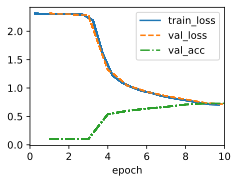

In [49]:
trainer = d2l.Trainer(max_epochs=10, num_gpus=1)
data = d2l.FashionMNIST(batch_size=128)
model = LeNet(lr=0.1)
model.apply_init([next(iter(data.get_dataloader(True)))[0]], init_cnn)
trainer.fit(model, data)

### 7.6.3. Summary

We have made significant progress in this chapter. We moved from the MLPs of the 1980s to the CNNs of the 1990s and early 2000s. The architectures proposed, e.g., in the form of LeNet-5 remain meaningful, even to this day. It is worth comparing the error rates on Fashion-MNIST achievable with LeNet-5 both to the very best possible with MLPs (Section 5.2) and those with significantly more advanced architectures such as ResNet (Section 8.6). LeNet is much more similar to the latter than to the former. One of the primary differences, as we shall see, is that greater amounts of computation enabled significantly more complex architectures.

A second difference is the relative ease with which we were able to implement LeNet. What used to be an engineering challenge worth months of C++ and assembly code, engineering to improve SN, an early Lisp-based deep learning tool (Bottou and Le Cun, 1988), and finally experimentation with models can now be accomplished in minutes. It is this incredible productivity boost that has democratized deep learning model development tremendously. In the next chapter we will journey down this rabbit to hole to see where it takes us.

### 7.6.4. Exercises

1. Let's modernize LeNet. Implement and test the following changes:
    - Replace average pooling with max-pooling.
    - Replace the softmax layer with ReLU.

1. Try to change the size of the LeNet style network to improve its accuracy in addition to max-pooling and ReLU.
    - Adjust the convolution window size.
    - Adjust the number of output channels.
    - Adjust the number of convolution layers.
    - Adjust the number of fully connected layers.
    - Adjust the learning rates and other training details (e.g., initialization and number of epochs).

1. Try out the improved network on the original MNIST dataset.

1. Display the activations of the first and second layer of LeNet for different inputs (e.g., sweaters and coats).

1. What happens to the activations when you feed significantly different images into the network (e.g., cats, cars, or even random noise)?